# 🛰️ LiDAR & Copernicus DEM Processing Workflow

This notebook demonstrates a full workflow to acquire, process, and compare high-resolution elevation datasets over a selected region of interest (ROI).

## ✅ Steps Overview

1) **Search for LiDAR datasets (50 cm² resolution)**  
   - Query available French LiDAR datasets.
   - Select a single dataset of interest.

2) **Define ROI & Identify Available Tiles**  
   - Specify a bounding box around the target area.
   - Locate all LiDAR tiles (1 km² each) intersecting the ROI.

3) **Download LiDAR Tiles DTM adn DSM**  
   - Retrieve only the required tiles.
   - Optionally merge and/or crop them to the ROI.
   - Downside the LiDAR Tiles DTM adn DSM resolution to 10 or 30m 

4) **Download Copernicus DSM (30 m resolution)**  
   - Retrieve lower-resolution data covering the same ROI.

5) **Compare**  
   - Plot LiDAR vs. Copernicus DEM.
   - Display with contextual basemap (e.g. `contextily`) for spatial reference.

---


In [4]:
# ─────────────────────────────────────────────────────────
# Standard library
# ─────────────────────────────────────────────────────────
import os
import sys
from urllib.parse import urlencode

# ─────────────────────────────────────────────────────────
# Third-party libraries
# ─────────────────────────────────────────────────────────
import numpy as np
import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
import requests
from lxml import etree
from pyproj import Transformer
from rasterio.io import MemoryFile
from rasterio.mask import mask
from rasterio.merge import merge
from rasterio.enums import Resampling
from rasterio.warp import reproject, calculate_default_transform, transform_bounds
from shapely.geometry import Point, box
import zipfile
from hda import Client
from pathlib import Path
import math
from affine import Affine
import time
import xml.etree.ElementTree as ET
import pandas as pd

In [11]:

def list_layers_wfs(url):
    params = {
        "SERVICE": "WFS",
        "REQUEST": "GetCapabilities",
        "VERSION": "2.0.0"
    }
    r = requests.get(url, params=params)
    r.raise_for_status()

    root = etree.fromstring(r.content)
    ns = {"wfs": "http://www.opengis.net/wfs/2.0"}

    layers = root.findall(".//wfs:FeatureType/wfs:Name", namespaces=ns)
    return [l.text for l in layers]

def download_tiles(sel_gdf, url_field, out_dir="tiles"):
    os.makedirs(out_dir, exist_ok=True)
    for idx, row in sel_gdf.iterrows():
        url = row[url_field]
        fname = os.path.join(out_dir, os.path.basename(url))
        if os.path.exists(fname):
            print("Already have", fname)
            continue
        print("Downloading", url)
        r = requests.get(url, stream=True)
        if r.status_code != 200:
            print("Failed:", url, r.status_code)
            continue
        with open(fname, 'wb') as f:
            for chunk in r.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)
            print("Saved to ", fname)
    print("Download complete.")

def filter_tiles(gdf, bbox):
    # bbox dict with lon_min, lat_min, lon_max, lat_max in same CRS
    import shapely.geometry as geom
    box_geom = geom.box(bbox["lon_min"], bbox["lat_min"], bbox["lon_max"], bbox["lat_max"])
    sel = gdf[gdf.intersects(box_geom)]
    return sel


def get_tile_index(layer_name, save_path=None):
    wfs_url = "https://data.geopf.fr/wfs/ows"
    params = {
        "SERVICE": "WFS",
        "VERSION": "2.0.0",
        "REQUEST": "GetFeature",
        "TYPENAMES": layer_name,
        "OUTPUTFORMAT": "application/json"
    }
    resp = requests.get(wfs_url, params=params, stream=True)
    resp.raise_for_status()
    geojson = resp.json()
    gdf = gpd.GeoDataFrame.from_features(geojson["features"], crs="EPSG:2154")  # assume EPSG:2154/Lambert‑93
    if save_path:
        gdf.to_file(save_path, driver="GPKG")
    return gdf



def plot_tile_centroids_with_basemap(gdf, name="LIDAR", crs_source="EPSG:2154", crs_target="EPSG:4326"):
    """
    Plot the centroids of all tiles on a map of France with basemap.
    
    Parameters:
        gdf : GeoDataFrame
            GeoDataFrame containing tile polygons in Lambert-93 (EPSG:2154)
        crs_source : str
            CRS of the input gdf (default EPSG:2154)
        crs_target : str
            CRS to transform centroids to (default EPSG:4326 / WGS84)
    """
    # Transformer Lambert-93 -> WGS84
    transformer = Transformer.from_crs(crs_source, crs_target, always_xy=True)
    
    # Compute centroids and transform coordinates
    centroids_lonlat = []
    for geom in gdf.geometry:
        if geom is None or geom.is_empty:
            continue
        centroid = geom.centroid

        lon, lat = transformer.transform(centroid.x, centroid.y)
        centroids_lonlat.append((lon, lat))
    
    # Create GeoDataFrame of points in WGS84
    points_gdf = gpd.GeoDataFrame(
        geometry=[Point(lon, lat) for lon, lat in centroids_lonlat],
        crs=crs_target
    )
        
    # Plot
    fig, ax = plt.subplots(figsize=(10, 12))
    points_gdf.plot(ax=ax, color="red", markersize=5, label="Tile centroids")
    
    # Add basemap using contextily
    cx.add_basemap(ax, crs=points_gdf.crs.to_string(), source=cx.providers.CartoDB.Voyager)
    
    ax.set_title(name)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.legend()
    plt.show()

def download_cop_dem(bbox, api_key, output_file):
    product = "COP30"

    # -----------------------
    # Build request URL
    # -----------------------
    API_URL = (
        "https://portal.opentopography.org/API/globaldem"
        f"?demtype={product}"
        f"&south={bbox['lat_min']}&north={bbox['lat_max']}"
        f"&west={bbox['lon_min']}&east={bbox['lon_max']}"
        "&outputFormat=GTiff"
        f"&API_Key={api_key}"
    )

    print("Request:", API_URL)

    # Download raster directly
    response = requests.get(API_URL, stream=True)

    if response.status_code != 200:
        print("\n❌ HTTP error:", response.status_code)
        print(response.text)
        raise SystemExit

    # Save to file
    with open(output_file, "wb") as f:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)

    print("✅ Saved →", output_file)

def download_contextly_image(bbox):
    """
    Downloads a contextual basemap image (e.g., for visualization) for the given bounding box.

    Parameters:
    - bbox (shapely.geometry.Polygon): Bounding box as a shapely box geometry.

    Returns:
    - cx_img (ndarray): Image array of the map tiles covering the bounding box.
    """

    cx_img, ext = cx.bounds2img(bbox["lon_min"],
                             bbox["lat_min"],
                             bbox["lon_max"],
                             bbox["lat_max"],
                             ll=True,
                             source=cx.providers.CartoDB.Voyager)

    return cx_img

def clip_and_merge_tiles(tile_paths, roi_geom, output_path):

    # Open datasets
    srcs = [rasterio.open(p) for p in tile_paths]

    # 1) Merge
    mosaic, mosaic_transform = merge(srcs)

    # Copy metadata
    meta = srcs[0].meta.copy()
    meta.update({
        "height": mosaic.shape[1],
        "width":  mosaic.shape[2],
        "transform": mosaic_transform
    })

    # Properly close
    for s in srcs:
        s.close()

    # 2) Clip
    with MemoryFile() as memfile:
        with memfile.open(**meta) as tmp:
            tmp.write(mosaic)

            clipped, clipped_transform = mask(
                tmp,
                [roi_geom],
                crop=True
            )

    # 3) Save output
    meta.update({
        "height": clipped.shape[1],
        "width":  clipped.shape[2],
        "transform": clipped_transform
    })

    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    with rasterio.open(output_path, "w", **meta) as dst:
        dst.write(clipped)

    return clipped, clipped_transform

def downsample_raster(input_path, output_path, scale_factor):
    """
    Downsample a raster by the given scale factor (e.g. 2 = half resolution).

    Parameters:
        input_path (str): path to input raster (.tif)
        output_path (str): where to save the result
        scale_factor (float): factor by which to reduce resolution
    """

    with rasterio.open(input_path) as src:
        # Original dimensions
        height = src.height
        width = src.width

        # New dimensions
        new_height = int(height / scale_factor)
        new_width  = int(width  / scale_factor)

        # Resample
        data = src.read(
            out_shape=(
                src.count,
                new_height,
                new_width
            ),
            resampling=Resampling.bilinear   # or nearest, cubic...
        )

        # Compute new transform
        new_transform = src.transform * src.transform.scale(
            (src.width / new_width),
            (src.height / new_height)
        )

        # Update metadata
        meta = src.meta.copy()
        meta.update({
            "height": new_height,
            "width": new_width,
            "transform": new_transform
        })

        # Ensure directory exists
        os.makedirs(os.path.dirname(output_path), exist_ok=True)

        # Write to output
        with rasterio.open(output_path, "w", **meta) as dst:
            dst.write(data)

    return data, new_transform

def reproject_raster(
    src_path,
    dst_path,
    dst_crs="EPSG:2154",
    dst_resolution=None,   # desired pixel size in CRS units (e.g. meters). If None, use calculate_default_transform behaviour.
    resampling=Resampling.bilinear,
    dst_dtype=None,
    nodata=None
):
    """
    Reproject a raster to dst_crs. If dst_resolution is provided, force square pixels of that size.
    Returns (dst_path, dst_transform).
    """
    with rasterio.open(src_path) as src:
        src_crs = src.crs
        src_bounds = src.bounds
        src_count = src.count
        src_dtype = src.dtypes[0]
        src_nodata = src.nodata if nodata is None else nodata
        if dst_dtype is None:
            dst_dtype = src_dtype

        # If user provided a resolution, compute dst bounds and exact width/height in dst_crs
        if dst_resolution is not None:
            # Transform source bounds to destination CRS (densify to better follow curves if needed)
            dst_bounds = transform_bounds(src_crs, dst_crs, *src_bounds, densify_pts=21)
            minx, miny, maxx, maxy = dst_bounds

            # compute integer sizes that cover the extent with requested pixel size
            width = int(math.ceil((maxx - minx) / dst_resolution))
            height = int(math.ceil((maxy - miny) / dst_resolution))

            # create a transform that places the top-left at minx,maxy and uses square pixels
            dst_transform = Affine(dst_resolution, 0.0, minx,
                                    0.0, -dst_resolution, maxy)

            # Recalculate exact maxx,maxy from integer grid (optional but useful)
            real_maxx = minx + width * dst_resolution
            real_miny = maxy - height * dst_resolution
        else:
            # If no resolution specified, use rasterio to compute transform/width/height automatically.
            from rasterio.warp import calculate_default_transform
            dst_transform, width, height = calculate_default_transform(
                src_crs, dst_crs, src.width, src.height, *src.bounds)
            # If the transform contains rotation this still yields correct dimensions,
            # but pixel sizes may not be perfectly equal if source has odd dimensions.
        
        # Build metadata for destination
        profile = src.meta.copy()
        profile.update({
            'crs': dst_crs,
            'transform': dst_transform,
            'width': width,
            'height': height,
            'dtype': dst_dtype,
            'count': src_count,
            'nodata': src_nodata,
            'compress': 'lzw'
        })

        # Write destination and reproject band by band
        with rasterio.open(dst_path, 'w', **profile) as dst:
            for i in range(1, src_count + 1):
                reproject(
                    source=rasterio.band(src, i),
                    destination=rasterio.band(dst, i),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=dst_transform,
                    dst_crs=dst_crs,
                    resampling=resampling,
                    dst_nodata=src_nodata
                )

    return dst_path, dst_transform


def reproject_to_match(src_path, dst_path, match_path, resampling=Resampling.bilinear):
    """
    Reproject a raster (src_path) so that it matches the CRS, transform, width, height
    and grid of a reference raster (match_path), then save as dst_path.
    
    Parameters:
        src_path : str
            Path to source raster to reproject.
        dst_path : str
            Path to output raster.
        match_path : str
            Path to reference raster (target grid).
        resampling : rasterio.warp.Resampling
            Resampling method (bilinear, average, nearest, etc.)
    Returns:
        dst_path, transform : str, Affine
            Output path and transform of reprojected raster.
    """
    with rasterio.open(match_path) as ref:
        dst_crs = ref.crs
        dst_transform = ref.transform
        dst_width = ref.width
        dst_height = ref.height
        dst_count = ref.count
        dst_nodata = np.nan

    with rasterio.open(src_path) as src:
        profile = src.meta.copy()
        profile.update({
            'crs': dst_crs,
            'transform': dst_transform,
            'width': dst_width,
            'height': dst_height,
            'dtype': 'float32',
            'count': src.count,
            'nodata': np.nan
        })

        with rasterio.open(dst_path, 'w', **profile) as dst:
            for i in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, i),
                    destination=rasterio.band(dst, i),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=dst_transform,
                    dst_crs=dst_crs,
                    resampling=resampling,
                    dst_nodata=np.nan
                )

    print("Reprojected raster saved to:", dst_path)
    return dst_path, dst_transform

def download_and_extract(product, out_dir, tmp_root="tmp_downloads"):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    tmp_root = Path(tmp_root)
    tmp_root.mkdir(parents=True, exist_ok=True)

    # product is a SearchResults object with 1 element → extract dict
    result = product.results[0]

    product_id = result["id"]
    expected_zip = Path(f"{product_id}.zip")

    print(f"Downloading {product_id} ...")

    # Trigger download (always goes to CWD)
    product.download()

    # Locate downloaded ZIP in CWD
    if not expected_zip.exists():
        raise FileNotFoundError(
            f"Expected zip {expected_zip} not found after download."
        )

    # Move ZIP to tmp_root
    zip_path = tmp_root / expected_zip.name
    shutil.move(str(expected_zip), str(zip_path))
    print("Stored ZIP at:", zip_path)

    # Extract
    print("Extracting...")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(out_dir)

    # Remove ZIP
    zip_path.unlink()

    # Return only .tif files
    tif_files = list(out_dir.glob("*.tif"))
    if not tif_files:
        raise RuntimeError(f"No .tif found in {out_dir}")

    return tif_files



### Settings

In [6]:
##### TO BE FILLED BY USER #####
api_key = "38b3211483d503ddd81882f2259b6201"   # <-- put your api key of opentopography here

base_dir = "/home/renauld/DSM/"
data_dir = os.path.join(base_dir, "data_test_multimodality")

area = "Caen"
# Define bbox in WGS84
lon_wgs84, lat_wgs84 = -0.3, 49.2  # Caen
box_size = 0.007 # degrees
#####

##### Create output directories #####
# Lidar DSM
lidar50cm_DSM_original_dir= os.path.join(data_dir, area, "lidar50cm_DSM_tiles")
lidar50cm_DSM_output_dir = os.path.join(data_dir, area, "lidar50cm_DSM_roi")
lidar30m_DSM_output_dir = os.path.join(data_dir, area, "lidar30m_DSM_roi")
os.makedirs(lidar50cm_DSM_original_dir, exist_ok=True)
os.makedirs(lidar50cm_DSM_output_dir, exist_ok=True)
os.makedirs(lidar30m_DSM_output_dir, exist_ok=True)
# Lidar DTM 
lidar50cm_DTM_original_dir= os.path.join(data_dir, area, "lidar50cm_DTM_tiles")
lidar50cm_DTM_output_dir = os.path.join(data_dir, area, "lidar50cm_DTM_roi")
lidar30m_DTM_output_dir = os.path.join(data_dir, area, "lidar30m_DTM_roi")
os.makedirs(lidar50cm_DTM_original_dir, exist_ok=True)
os.makedirs(lidar50cm_DTM_output_dir, exist_ok=True)
os.makedirs(lidar30m_DTM_output_dir, exist_ok=True)

# COPERNICUS 30m DEM
cop_dir = os.path.join(data_dir, area, "cop30m_roi")
os.makedirs(cop_dir, exist_ok=True)
#####

##### Coordinate transformers from WGS84 to Lambert-93 #####
transformer_to_l93 = Transformer.from_crs("EPSG:4326", "EPSG:2154", always_xy=True)
transformer_to_wgs84 = Transformer.from_crs("EPSG:2154", "EPSG:4326", always_xy=True)

lon_min_wgs84, lat_min_wgs84 = lon_wgs84 - box_size, lat_wgs84 - box_size
lon_max_wgs84, lat_max_wgs84 = lon_wgs84 + box_size, lat_wgs84 + box_size
bbox_wgs84 = {"lon_min": lon_min_wgs84, "lat_min": lat_min_wgs84, "lon_max": lon_max_wgs84, "lat_max": lat_max_wgs84}

# Convert bbox to Lambert-93
lon_min_l93, lat_min_l93 = transformer_to_l93.transform(lon_min_wgs84, lat_min_wgs84)
lon_max_l93, lat_max_l93 = transformer_to_l93.transform(lon_max_wgs84, lat_max_wgs84)
bbox_l93 = {"lon_min": lon_min_l93, "lat_min": lat_min_l93, "lon_max": lon_max_l93, "lat_max": lat_max_l93}
roi_geom_l93 = box(lon_min_l93, lat_min_l93, lon_max_l93, lat_max_l93)
#####


### Visualize the available Lidar database on the the IGN WFS endpoint


In [97]:
# layers = list_layers_wfs("https://data.geopf.fr/wfs/ows")

# lidar_layers = [l for l in layers if "LIDAR" in l.upper()]
# print("Available LiDAR layers:")
# for layer in lidar_layers:
#     gdf = get_tile_index(layer)

#     print("Number of tiles:", len(gdf))
#     name = f"{layer}, {len(gdf)} tiles"
#     plot_tile_centroids_with_basemap(gdf, name)

### Select the MNS:dalle and MNT:dalle
* MNS means "modele numerique de surface" stands for DSM (Digital Surface Model)
* MNT means "modele numerique de terrain" stands for DST (Digital Terrain Model)

# From this database we will
* Find the titles that intersect our ROI
* Download them in the lidar_dir

In [ ]:
##### DSM
layer_DSM = "IGNF_LIDAR-HD_MNS_GRAPHE-MOSAIQUAGE:mns-dalle"
gdf_DSM = get_tile_index(layer_DSM)
print("Available DSM tiles:", len(gdf_DSM))
print(gdf_DSM.keys())
print(gdf_DSM['url'].values[0:5])


print("DSM, BBox in Lambert-93:", bbox_l93)
sel_DSM = filter_tiles(gdf_DSM, bbox_l93)
print("Selected tiles: ", len(sel_DSM))

download_tiles(sel_DSM, url_field="url", out_dir=lidar50cm_DSM_original_dir)

##### DTM
layer_DTM = "IGNF_LIDAR-HD_MNT_GRAPHE-MOSAIQUAGE:mnt-dalle"
gdf_DTM = get_tile_index(layer_DTM)

print("DTM, BBox in Lambert-93:", bbox_l93)
sel_DTM = filter_tiles(gdf_DTM, bbox_l93)
print("Selected tiles: ", len(sel_DTM))

download_tiles(sel_DTM, url_field="url", out_dir=lidar50cm_DTM_original_dir)

Available DSM tiles: 5000
Index(['geometry', 'name', 'url', 'srs'], dtype='object')
['https://data.geopf.fr/wms-r/LHD_FXX_0506_6757_MNS_O_0M50_LAMB93_IGN69.tif?SERVICE=WMS&VERSION=1.3.0&EXCEPTIONS=text/xml&REQUEST=GetMap&LAYERS=IGNF_LIDAR-HD_MNS_ELEVATION.ELEVATIONGRIDCOVERAGE.LAMB93&FORMAT=image/geotiff&STYLES=&CRS=EPSG:2154&BBOX=505999.75,6756000.25,506999.75,6757000.25&WIDTH=2000&HEIGHT=2000&FILENAME=LHD_FXX_0506_6757_MNS_O_0M50_LAMB93_IGN69.tif'
 'https://data.geopf.fr/wms-r/LHD_FXX_0518_6752_MNS_O_0M50_LAMB93_IGN69.tif?SERVICE=WMS&VERSION=1.3.0&EXCEPTIONS=text/xml&REQUEST=GetMap&LAYERS=IGNF_LIDAR-HD_MNS_ELEVATION.ELEVATIONGRIDCOVERAGE.LAMB93&FORMAT=image/geotiff&STYLES=&CRS=EPSG:2154&BBOX=517999.75,6751000.25,518999.75,6752000.25&WIDTH=2000&HEIGHT=2000&FILENAME=LHD_FXX_0518_6752_MNS_O_0M50_LAMB93_IGN69.tif'
 'https://data.geopf.fr/wms-r/LHD_FXX_0518_6760_MNS_O_0M50_LAMB93_IGN69.tif?SERVICE=WMS&VERSION=1.3.0&EXCEPTIONS=text/xml&REQUEST=GetMap&LAYERS=IGNF_LIDAR-HD_MNS_ELEVATION.ELEV

SystemExit: -1

/opt/conda/envs/ri-ml-base/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [224]:
def build_metadata_url(tile_name):
    """Convert tile name to IGN WFS metadata query."""
    # Keep only the grid ID part: LHD_FXX_0506_6757
    base_id = "_".join(tile_name.split("_")[:4])

    filter_xml = (
        f"<Filter>"
        f"<PropertyIsEqualTo>"
        f"<PropertyName>name</PropertyName>"
        f"<Literal>{base_id}</Literal>"
        f"</PropertyIsEqualTo>"
        f"</Filter>"
    )

    url = (
        "https://data.geopf.fr/wfs/ows?"
        "SERVICE=WFS&VERSION=2.0.0&REQUEST=GetFeature&"
        "TYPENAME=LIDARHD:POINTCLOUDCOVERAGE&"
        f"FILTER={filter_xml}"
    )
    return url


def fetch_tile_metadata(tile_row):
    """Fetch metadata for a single tile (GeoDataFrame row)."""
    tile_name = tile_row["name"]
    url = build_metadata_url(tile_name)

    r = requests.get(url)
    if r.status_code != 200:
        return None

    root = ET.fromstring(r.text)

    start_date, end_date = None, None
    bbox = {}

    for elem in root.iter():
        tag = elem.tag.lower()
        if "startdate" in tag:
            start_date = elem.text
        elif "enddate" in tag:
            end_date = elem.text
        elif "lowercorner" in tag:
            bbox["lower"] = elem.text
        elif "uppercorner" in tag:
            bbox["upper"] = elem.text

    return {
        "name": tile_name,
        "start_date": start_date,
        "end_date": end_date,
        "year": start_date[:4] if start_date else None,
        "bbox_lower": bbox.get("lower"),
        "bbox_upper": bbox.get("upper")
    }


def fetch_all_metadata(gdf_DSM):
    results = []

    for idx, row in gdf_DSM.iterrows():
        print(f"[{idx+1}/{len(gdf_DSM)}] Fetching: {row['name']}")
        meta = fetch_tile_metadata(row)
        if meta:
            results.append(meta)
        time.sleep(0.2)

    df_meta = pd.DataFrame(results)
    return gdf_DSM.merge(df_meta, on="name", how="left")

In [ ]:
# def fetch_tile_metadata(tile, max_retries=3, sleep_time=0.5):
#     """Fetch metadata for a single DSM tile from its WMS GetMap URL."""

#     url = tile["url"]  # correct extraction

#     # Attempt request with retries
#     for attempt in range(max_retries):
#         r = requests.get(url)
#         if r.status_code == 200:
#             break
#         time.sleep(sleep_time)
#     else:
#         print(f"[WARN] Request failed: {tile['name']}")
#         return None

#     # Parse XML
#     root = ET.fromstring(r.content)

#     start_date, end_date = None, None
#     bbox = {}

#     for elem in root.iter():
#         tag = elem.tag.lower()
#         if "startdate" in tag:
#             start_date = elem.text
#         elif "enddate" in tag:
#             end_date = elem.text
#         elif "lowercorner" in tag:
#             bbox["lower"] = elem.text
#         elif "uppercorner" in tag:
#             bbox["upper"] = elem.text

#     return {
#         "name": tile["name"],  # THIS is critical and now correct
#         "start_date": start_date,
#         "end_date": end_date,
#         "year": start_date[:4] if start_date else None,
#         "bbox_lower": bbox.get("lower"),
#         "bbox_upper": bbox.get("upper")
#     }

# def fetch_all_metadata(gdf_DSM):
#     results = []

#     for i, (idx, row) in enumerate(gdf_DSM.iterrows()):
#         print(f"[{i+1}/{len(gdf_DSM)}] Fetching metadata for {row['name']}")
#         meta = fetch_tile_metadata(row)
#         if meta:
#             results.append(meta)
#         time.sleep(0.2)  # rate limit

#     df_meta = pd.DataFrame(results)

#     # Safe merge on 'name'
#     gdf_out = gdf_DSM.merge(df_meta, on="name", how="left")
#     return gdf_out

In [225]:
# print(sel_DSM.columns)
# sys.exit(-1)

gdf_with_meta = fetch_all_metadata(sel_DSM)
print(sel_DSM["url"])

[2849/6] Fetching: LHD_FXX_0458_6906_MNS_O_0M50_LAMB93_IGN69.tif
[3312/6] Fetching: LHD_FXX_0459_6905_MNS_O_0M50_LAMB93_IGN69.tif
[3399/6] Fetching: LHD_FXX_0460_6906_MNS_O_0M50_LAMB93_IGN69.tif
[3818/6] Fetching: LHD_FXX_0458_6905_MNS_O_0M50_LAMB93_IGN69.tif
[3945/6] Fetching: LHD_FXX_0460_6905_MNS_O_0M50_LAMB93_IGN69.tif
[4011/6] Fetching: LHD_FXX_0459_6906_MNS_O_0M50_LAMB93_IGN69.tif


KeyError: 'name'

In [ ]:
# bbox = [
#         9.425764239078317,
#         42.74275713340862,
#         9.735642520957134,
#         43.05969192516483
#     ]

startDate = "2020-01-01T00:00:00.000Z"
completionDate = "2021-01-01T00:00:00.000Z"

# # Your JSON file:
# S2_request = {
#     "dataset_id": "EO:ESA:DAT:SENTINEL-2",
#     "bbox": bbox,
#     "startDate": startDate,
#     "completionDate": completionDate,
#     "processingLevel": "S2MSI2A"
# }

# S2_matches = hda_client.search(S2_request)
# print("Sentinel 2:")
# print(S2_matches)

TCF_request = {
    "dataset_id": "EO:EEA:DAT:HRL:TCF", # Tree Cover Fraction, 
    "bbox": bbox,
    # "startDate": startDate,
    # "completionDate": completionDate
}

TCF_matches = hda_client.search(TCF_request)
print("Tree Cover Fraction:")
print(TCF_matches[-1])

download_TCF_dir = "/workspaces/DSM/data/TCF_original/"
os.makedirs(download_TCF_dir, exist_ok=True)
print("Downloading ...")
TCF_matches[-1].download(download_TCF_dir)
print("Download completed.")

    
IMD_request = {
  "dataset_id": "EO:EEA:DAT:HRL:IMP", # Impervious Built-Up Area
  "bbox": bbox,
    # "startDate": startDate,
    # "completionDate": completionDate
}

download_IMD_dir = "/workspaces/DSM/data/IMD_original/"
os.makedirs(download_IMD_dir, exist_ok=True)
IMD_matches = hda_client.search(IMD_request)
print("Impervious Built-Up Area:")
print(IMD_matches)
IMD_matches[-1].download(download_IMD_dir)
print("Download completed.")

Tree Cover Fraction:
SearchResults[items=1,volume=21.9MB]


Download completed.


* We can visualize all the titles we downloaded

In [241]:
vmin = -5
os.chdir(lidar50cm_DSM_original_dir)
print("Files in directory:", lidar50cm_DSM_original_dir)





for root, dirs, files in os.walk(lidar50cm_DSM_original_dir):
    for f in files:
        if f.endswith(".tif"):
            file_path = os.path.join(root, f)
            print("Opening:", file_path)
            print_lidar_metadata(file_path)
            sys.exit(-1)

            with rasterio.open(file_path) as src:
                print("\n--- RASTER METADATA ---")
                for k, v in src.meta.items():
                    print(f"{k}: {v}")
                sys.exit(-1)

                dem = src.read(1)
                print(src.meta.items())
                sys.exit(-1)
                transform = src.transform  # affine transform

                # Get bounds (xmin, ymin, xmax, ymax)
                bounds = src.bounds
                extent = (bounds.left, bounds.right, bounds.bottom, bounds.top)

                plt.figure(figsize=(8,6))
                plt.imshow(
                    dem,
                    cmap="terrain",
                    extent=extent,      # <-- HERE
                    origin="upper", 
                    vmin = vmin
                )
                plt.colorbar(label="Elevation (m)")
                plt.title("IGN LiDAR-HD MNS")
                plt.xlabel("X (meters)")
                plt.ylabel("Y (meters)")
                plt.show()


Files in directory: /home/renauld/DSM/data_test_multimodality/Caen/lidar50cm_DSM_tiles
Opening: /home/renauld/DSM/data_test_multimodality/Caen/lidar50cm_DSM_tiles/geotiff&STYLES=&CRS=EPSG:2154&BBOX=457999.75,6905000.25,458999.75,6906000.25&WIDTH=2000&HEIGHT=2000&FILENAME=LHD_FXX_0458_6906_MNS_O_0M50_LAMB93_IGN69.tif

===== TILE: /home/renauld/DSM/data_test_multimodality/Caen/lidar50cm_DSM_tiles/geotiff&STYLES=&CRS=EPSG:2154&BBOX=457999.75,6905000.25,458999.75,6906000.25&WIDTH=2000&HEIGHT=2000&FILENAME=LHD_FXX_0458_6906_MNS_O_0M50_LAMB93_IGN69.tif =====

--- BASIC INFO ---
CRS: PROJCS["EPSG:2154",GEOGCS["unknown",DATUM["unnamed",SPHEROID["unretrievable - using WGS84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",46.5],PARAMETER["central_meridian",3],PARAMETER["standard_parallel_1",49],PARAMETER["standard_parallel_2",44],PARAMETER["false_easting",700000],PA

SystemExit: -1

/opt/conda/envs/ri-ml-base/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [240]:

def print_lidar_metadata(path):
    print("\n===== TILE:", path, "=====")
    
    with rasterio.open(path) as src:
        # Basic info
        print("\n--- BASIC INFO ---")
        print("CRS:", src.crs)
        print("Bounds:", src.bounds)
        print("Resolution:", src.res)
        print("Width x Height:", src.width, "x", src.height)
        
        # All raw metadata
        print("\n--- RASTER METADATA ---")
        for k, v in src.meta.items():
            print(f"{k}: {v}")

        # Tags (where acquisition info is stored)
        tags = src.tags()
        print("\n--- TIFF TAGS ---")
        for k, v in tags.items():
            print(f"{k}: {v}")

        # Tags per band
        print("\n--- BAND TAGS ---")
        for band in src.indexes:
            btags = src.tags(band)
            if btags:
                print(f"\nBand {band}:")
                for k, v in btags.items():
                    print(f"  {k}: {v}")

* Recombine them to obtain the expected ROI 
* Save the result in lidar_output_dir
* Visualize it

In [100]:
##### Process DSM #####
output_lidar50cm_DSM = os.path.join(lidar50cm_DSM_output_dir, f"{area}_Lidar50cm_DSM.tif")
tile_paths = [os.path.join(lidar50cm_DSM_original_dir, f) for f in os.listdir(lidar50cm_DSM_original_dir) if f.endswith(".tif")]

clipped_lidar50cm_DSM, clipped_transform_lidar50cm_DSM = clip_and_merge_tiles(tile_paths, roi_geom_l93, output_lidar50cm_DSM)

pixel_width  = clipped_transform_lidar50cm_DSM.a
pixel_height = abs(clipped_transform_lidar50cm_DSM.e)

print("Pixel resolution:", pixel_width, "x", pixel_height, "meters")


output_lidar30m_DSM = os.path.join(lidar30m_DSM_output_dir, f"{area}_Lidar30m_DSM.tif")
lidar30m_DSM, transform_30m = downsample_raster(output_lidar50cm_DSM, output_lidar30m_DSM, scale_factor=60)

pixel_width  = transform_30m.a
pixel_height = abs(transform_30m.e)

print("Pixel resolution:", pixel_width, "x", pixel_height, "meters")


##### Process DTM #####
output_lidar50cm_DTM = os.path.join(lidar50cm_DTM_output_dir, f"{area}_Lidar50_cm_DTM.tif")
tile_paths = [os.path.join(lidar50cm_DTM_original_dir, f) for f in os.listdir(lidar50cm_DTM_original_dir) if f.endswith(".tif")]

clipped_lidar50cm_DTM, clipped_transform_lidar50cm_DTM = clip_and_merge_tiles(tile_paths, roi_geom_l93, output_lidar50cm_DTM)

output_lidar30m_DTM = os.path.join(lidar30m_DTM_output_dir, f"{area}_Lidar30m_DTM.tif")
lidar30m_DTM, transform = downsample_raster(output_lidar50cm_DTM, output_lidar30m_DTM, scale_factor=60)

Pixel resolution: 0.5 x 0.5 meters
Pixel resolution: 30.13888888888889 x 30.28 meters


### Download Copernicus data
* DSM 30m resolution
* Available everywhere in the world
* Just need the bounding box (no need to recombine tiles)

In [101]:

output_cop = os.path.join(cop_dir, f"{area}_cop_dem30m.tif")
download_cop_dem(bbox_wgs84, api_key, output_cop)

# Get bounds (xmin, ymin, xmax, ymax)
with rasterio.open(output_cop) as src:
    cop30m_DSM = src.read(1)

    bounds = src.bounds
    extent = (bounds.left, bounds.right, bounds.bottom, bounds.top)    

    transform = src.transform  # affine transform
    pixel_width  = transform.a
    pixel_height = abs(transform.e)
    print("Pixel resolution COP DEM:", pixel_width, "x", pixel_height, "meters")

Request: https://portal.opentopography.org/API/globaldem?demtype=COP30&south=49.193000000000005&north=49.207&west=-0.307&east=-0.293&outputFormat=GTiff&API_Key=38b3211483d503ddd81882f2259b6201
✅ Saved → /home/renauld/DSM/data_test_multimodality/Caen/cop30m_roi/Caen_cop_dem30m.tif
Pixel resolution COP DEM: 0.0002777777777777778 x 0.0002777777777777778 meters


In [102]:
##### Process DSM #####
output_lidar50cm_DSM = os.path.join(lidar50cm_DSM_output_dir, f"{area}_Lidar50cm_DSM.tif")
tile_paths = [os.path.join(lidar50cm_DSM_original_dir, f) for f in os.listdir(lidar50cm_DSM_original_dir) if f.endswith(".tif")]

clipped_lidar50cm_DSM, clipped_transform_lidar50cm_DSM = clip_and_merge_tiles(tile_paths, roi_geom_l93, output_lidar50cm_DSM)

pixel_width  = clipped_transform_lidar50cm_DSM.a
pixel_height = abs(clipped_transform_lidar50cm_DSM.e)

print("Pixel resolution:", pixel_width, "x", pixel_height, "meters")
print("Shape:", clipped_lidar50cm_DSM.shape)


output_lidar30m_DSM = os.path.join(lidar30m_DSM_output_dir, f"{area}_Lidar30m_DSM.tif")
lidar30m_DSM, transform_30m = downsample_raster(output_lidar50cm_DSM, output_lidar30m_DSM, scale_factor=60)

pixel_width  = transform_30m.a
pixel_height = abs(transform_30m.e)

print("Pixel resolution:", pixel_width, "x", pixel_height, "meters")
print("Shape:", lidar30m_DSM.shape)

# Get bounds (xmin, ymin, xmax, ymax)
with rasterio.open(output_cop) as src:
    cop30m_DSM = src.read(1)

    bounds = src.bounds
    extent = (bounds.left, bounds.right, bounds.bottom, bounds.top)    

    transform = src.transform  # affine transform
    pixel_width  = transform.a
    pixel_height = abs(transform.e)
    print("Pixel resolution COP DEM:", pixel_width, "x", pixel_height, "meters")
    print("Shape COP DEM:", cop30m_DSM.shape)

Pixel resolution: 0.5 x 0.5 meters
Shape: (1, 3028, 2170)
Pixel resolution: 30.13888888888889 x 30.28 meters
Shape: (1, 50, 36)
Pixel resolution COP DEM: 0.0002777777777777778 x 0.0002777777777777778 meters
Shape COP DEM: (50, 50)


In [103]:
def inspect_raster(path, label="raster"):
    with rasterio.open(path) as src:
        print(f"--- {label} ---")
        print("CRS:", src.crs)
        print("Width x Height:", src.width, "x", src.height)
        print("Count (bands):", src.count)
        print("Transform:", src.transform)
        print("Pixel size (from transform):", src.transform.a, "x", abs(src.transform.e), " (units of CRS)")
        print("Bounds:", src.bounds)
        print()

# Example usage
inspect_raster(output_lidar50cm_DSM, "clipped 50cm DSM")
inspect_raster(output_lidar30m_DSM, "downsampled 30m DSM")
inspect_raster(output_cop, "COP DEM")

--- clipped 50cm DSM ---
CRS: PROJCS["EPSG:2154",GEOGCS["unknown",DATUM["unnamed",SPHEROID["unretrievable - using WGS84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",46.5],PARAMETER["central_meridian",3],PARAMETER["standard_parallel_1",49],PARAMETER["standard_parallel_2",44],PARAMETER["false_easting",700000],PARAMETER["false_northing",6600000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Width x Height: 2170 x 3028
Count (bands): 1
Transform: | 0.50, 0.00, 458990.25|
| 0.00,-0.50, 6905813.25|
| 0.00, 0.00, 1.00|
Pixel size (from transform): 0.5 x 0.5  (units of CRS)
Bounds: BoundingBox(left=458990.25, bottom=6904299.25, right=460075.25, top=6905813.25)

--- downsampled 30m DSM ---
CRS: PROJCS["EPSG:2154",GEOGCS["unknown",DATUM["unnamed",SPHEROID["unretrievable - using WGS84",6378137,298.257223563]],PRIMEM["Greenwi

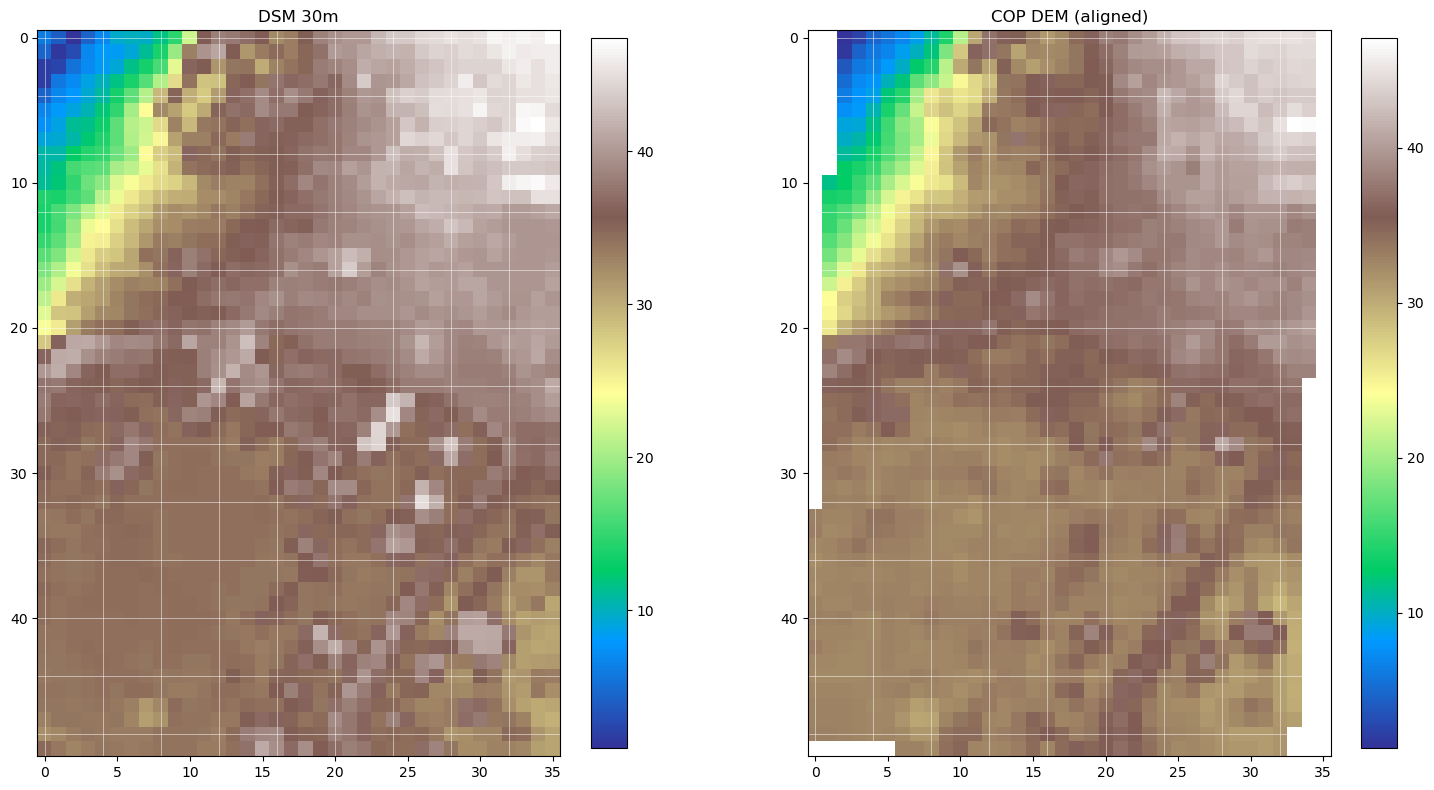

In [104]:
cop_on_dsm_grid = os.path.join(data_dir, f"{area}_cop_dem30m_on_lidar30m_grid.tif")
reproject_to_match(
    src_path=output_cop,               # COP DEM
    dst_path=cop_on_dsm_grid,          # aligned output
    match_path=output_lidar30m_DSM,    # reference raster grid
    resampling=rasterio.warp.Resampling.bilinear  # or Resampling.average
)

# Open rasters
with rasterio.open(output_lidar30m_DSM) as dsm, rasterio.open(cop_on_dsm_grid) as cop:
    dsm_arr = dsm.read(1)
    cop_arr = cop.read(1)

# Parameters
grid_step = 4  # draw a grid line every 4 pixels

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Function to add grid lines
def add_grid(ax, shape, step):
    for x in range(0, shape[1], step):
        ax.axvline(x, color='white', linewidth=0.5, alpha=0.7)
    for y in range(0, shape[0], step):
        ax.axhline(y, color='white', linewidth=0.5, alpha=0.7)

# Left: DSM
im1 = axes[0].imshow(dsm_arr, cmap="terrain")
add_grid(axes[0], dsm_arr.shape, grid_step)
axes[0].set_title("DSM 30m")

# Right: COP DEM
im2 = axes[1].imshow(cop_arr, cmap="terrain")
add_grid(axes[1], cop_arr.shape, grid_step)
axes[1].set_title("COP DEM (aligned)")

# Colorbars
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

Reprojected: /home/renauld/DSM/data_test_multimodality/cop_dem_30m_l93.tif
Transform: | 30.00, 0.00, 458985.17|
| 0.00,-30.00, 6905865.13|
| 0.00, 0.00, 1.00|
Pixel size: 30.0 30.0
Shape: (53, 36)


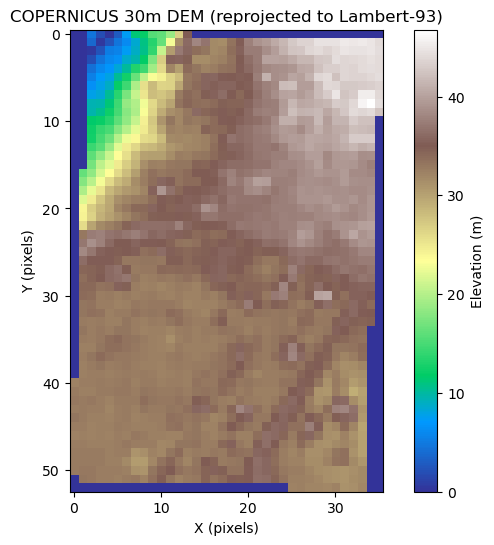

In [105]:
cop30m_path = os.path.join(data_dir, "cop_dem_30m_l93.tif")
dst_path, dst_transform = reproject_raster(
    src_path=output_cop,       # your original COP DEM in EPSG:4326
    dst_path=cop30m_path,
    dst_crs="EPSG:2154",
    dst_resolution=30.0,       # meters per pixel, will be square
    resampling=Resampling.bilinear  # or Resampling.average for downsample
)
print("Reprojected:", dst_path)
print("Transform:", dst_transform)
print("Pixel size:", dst_transform.a, abs(dst_transform.e))

with rasterio.open(dst_path) as src:
    cop30m_l93 = src.read(1)
    print("Shape:", cop30m_l93.shape)
    plt.figure(figsize=(8,6))
    plt.imshow(
        cop30m_l93,
        cmap="terrain",
        origin="upper"
    )
    plt.colorbar(label="Elevation (m)")
    plt.title("COPERNICUS 30m DEM (reprojected to Lambert-93)")
    plt.xlabel("X (pixels)")
    plt.ylabel("Y (pixels)")
    plt.show()

### Download contexly image

In [106]:
cx_image = download_contextly_image(bbox_wgs84)


### Visualize the data
* Download a contextly image
* Plot the 3 images together (will and without equal max)

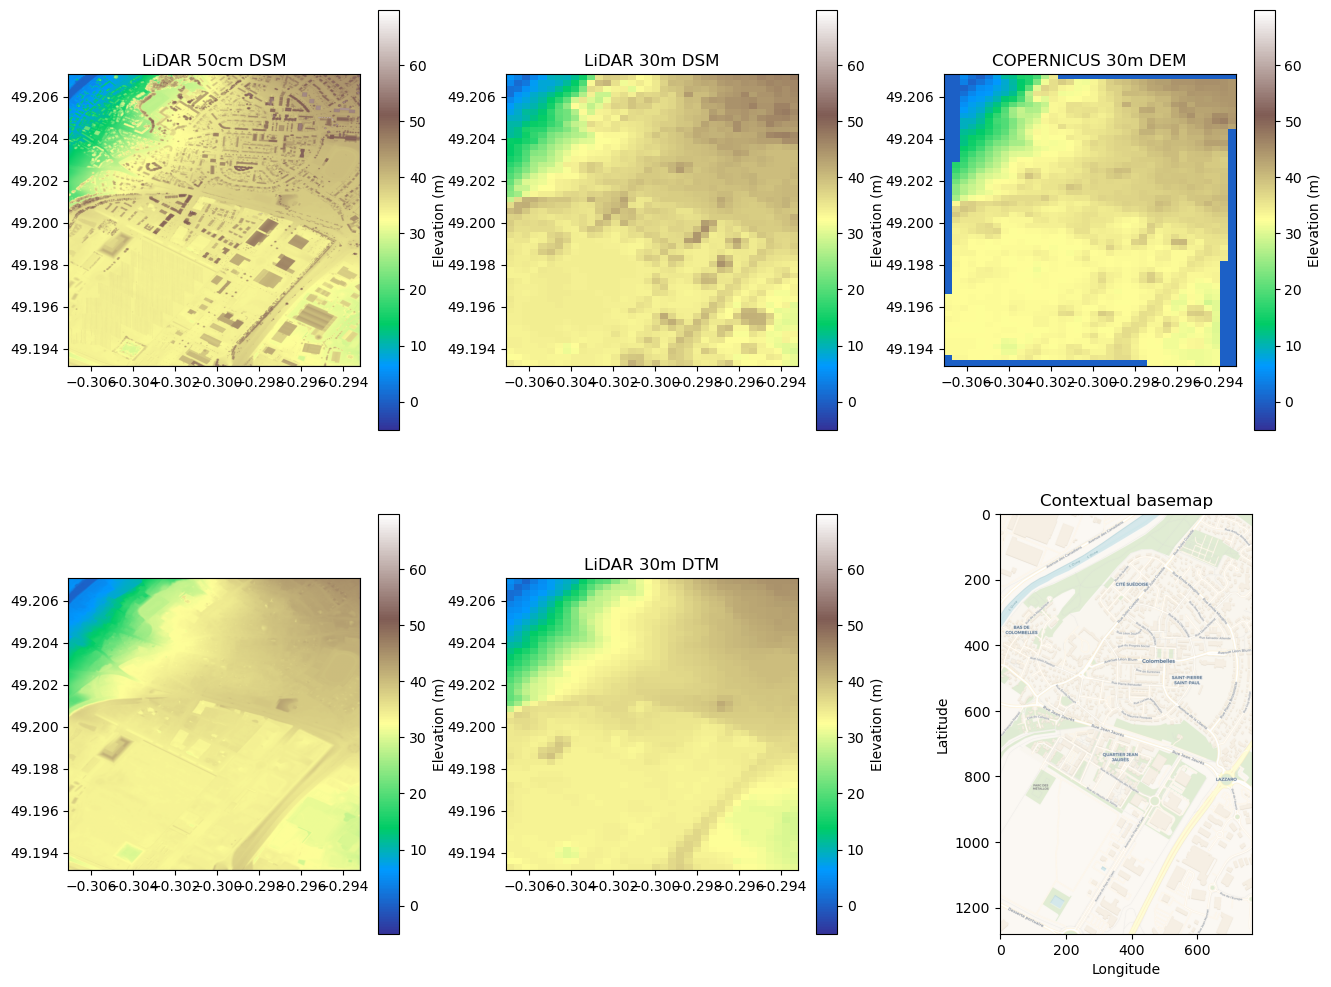

In [107]:
vmin = -5  
vmax = clipped_lidar50cm_DSM.max()

fig, ax = plt.subplots(2, 3, figsize=(16, 12))

im0 = ax[0, 0].imshow(
        clipped_lidar50cm_DSM[0],
        cmap="terrain",
        extent=extent,      # <-- HERE
        origin="upper", 
        vmin = vmin, 
        vmax = vmax
    )
ax[0,0].set_title("LiDAR 50cm DSM")
fig.colorbar(im0, ax=ax[0, 0], label="Elevation (m)")

im1 = ax[0,1].imshow(
        lidar30m_DSM[0],
        cmap="terrain",
        extent=extent,      # <-- HERE
        origin="upper", 
        vmin = vmin,
        vmax = vmax
    )
ax[0,1].set_title("LiDAR 30m DSM")
fig.colorbar(im1, ax=ax[0, 1], label="Elevation (m)")

im2 = ax[0,2].imshow(
        cop30m_l93,
        cmap="terrain",
        extent=extent,      # <-- HERE
        origin="upper", 
        vmin = vmin,
        vmax = vmax
    )
ax[0,2].set_title("COPERNICUS 30m DEM")
fig.colorbar(im2, ax=ax[0, 2], label="Elevation (m)")

im3 = ax[1,0].imshow(
        clipped_lidar50cm_DTM[0],
        cmap="terrain",
        extent=extent,      # <-- HERE
        origin="upper", 
        vmin = vmin,
        vmax = vmax
    )

fig.colorbar(im3, ax=ax[1, 0], label="Elevation (m)")

im4 = ax[1,1].imshow(
        lidar30m_DTM[0],
        cmap="terrain",
        extent=extent,      # <-- HERE
        origin="upper", 
        vmin = vmin,
        vmax = vmax
    )
ax[1,1].set_title("LiDAR 30m DTM")
fig.colorbar(im4, ax=ax[1, 1], label="Elevation (m)")

ax[1,2].imshow(cx_image)
ax[1,2].set_xlabel("Longitude")
ax[1,2].set_ylabel("Latitude")
ax[1,2].set_title("Contextual basemap")
plt.show()

In [108]:
print(clipped_lidar50cm_DSM[0].shape, "pixels in clipped LiDAR 50cm DSM")
print(lidar30m_DSM[0].shape, "pixels in LiDAR 30m DSM")
print(cop30m_DSM.shape, "pixels in COPERNICUS 30m DEM")

(3028, 2170) pixels in clipped LiDAR 50cm DSM
(50, 36) pixels in LiDAR 30m DSM
(50, 50) pixels in COPERNICUS 30m DEM


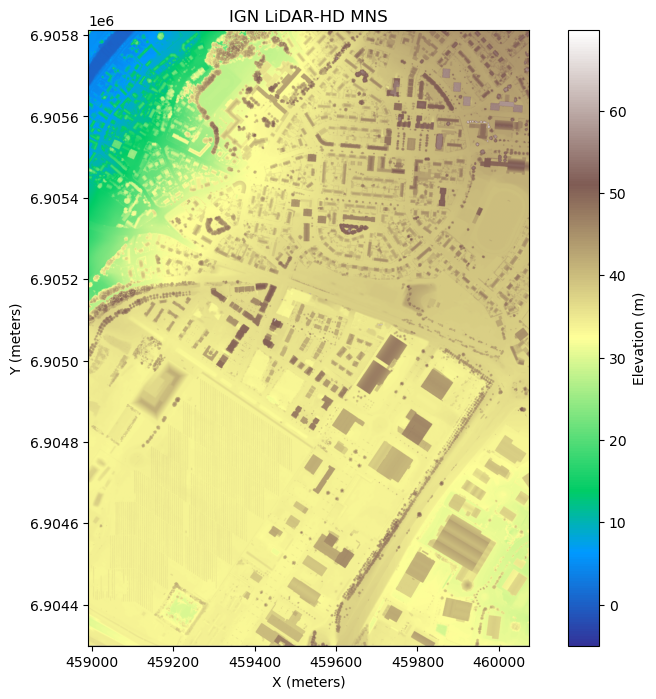

In [109]:
with rasterio.open(output_lidar50cm_DSM) as src:
    lidar_image = src.read(1)

    # Get bounds (xmin, ymin, xmax, ymax)
    bounds = src.bounds
    extent = (bounds.left, bounds.right, bounds.bottom, bounds.top)

    plt.figure(figsize=(10,8))
    plt.imshow(
        lidar_image,
        cmap="terrain",
        extent=extent,      # <-- HERE
        origin="upper", 
        vmin = vmin
    )
    plt.colorbar(label="Elevation (m)")
    plt.title(f"IGN LiDAR-HD MNS")
    plt.xlabel("X (meters)")
    plt.ylabel("Y (meters)")
    plt.show()

In [247]:
hda_client = Client()

# Search
TCF_matches = hda_client.search({
    "dataset_id": "EO:EEA:DAT:HRL:TCF",
    "bbox": [lon_min_wgs84, lat_min_wgs84, lon_max_wgs84, lat_max_wgs84]
})

print("Tree Cover Fraction:")
print(TCF_matches)

sys.exit()

# Download + extract latest one
TCF_dir = os.path.join(data_dir, area, "TCF_original/")
TCF_files = download_and_extract(TCF_matches[-1],
                             out_dir=TCF_dir,
                             tmp_root="/workspaces/DSM/data/tmp")

# Search
IMP_matches = hda_client.search({
    "dataset_id": "EO:EEA:DAT:HRL:IMP",
    "bbox": [lon_min_wgs84, lat_min_wgs84, lon_max_wgs84, lat_max_wgs84]
})


print("Imperviousness:")
print(IMP_matches[-1])

# Download + extract latest one
IMP_dir = os.path.join(data_dir, area, "IMP_original/")
IMP_files = download_and_extract(IMP_matches[-1],
                             out_dir=IMP_dir,
                             tmp_root="/workspaces/DSM/data/tmp")
# print("Extracted files:", files)

Tree Cover Fraction:
SearchResults[items=51,volume=258.8MB]


SystemExit: 

/opt/conda/envs/ri-ml-base/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [134]:

# Extract and group by year
datasets_by_year = {}
for item in TCF_matches:
    # Check if there is a 'beginTime' or 'time' field
    date_str = item.get('beginTime') or item.get('time')  # adapt to actual field name
    if date_str:
        year = datetime.strptime(date_str[:10], "%Y-%m-%d").year
        datasets_by_year.setdefault(year, []).append(item)
    else:
        datasets_by_year.setdefault('Unknown', []).append(item)

# Now you can see which years are available
print("Available years in TCF dataset:")
for year in sorted(datasets_by_year.keys()):
    print(year, len(datasets_by_year[year]), "datasets")


AttributeError: 'SearchResults' object has no attribute 'get'

In [135]:
help(TCF_matches)

Help on SearchResults in module hda.api object:

class SearchResults(builtins.object)
 |  SearchResults(client, results, dataset)
 |
 |  A wrapper to a data request response payload.
 |
 |  It adds aggregated information, like the total size and lenght of the results,
 |  and the ability to slice them.
 |
 |  Please refer to the :doc:`usage` page for examples.
 |
 |  :param client: The :class:`hda.api.Client` instance to be used to
 |      perform the download.
 |  :type client: :class:`hda.api.Client`
 |  :param results: The results list coming from the data request.
 |  :type results: list
 |  :param dataset: The dataset identifier.
 |  :type dataset: string
 |
 |  Methods defined here:
 |
 |  __getitem__(self, index)
 |
 |  __init__(self, client, results, dataset)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  __len__(self)
 |
 |  __repr__(self)
 |      Return repr(self).
 |
 |  download(self, download_dir: str = '.', force=False)
 |      Downloads the

In [162]:
print("Number of datasets found:", len(TCF_matches))
first_item = TCF_matches[0]  # get the first dataset
print(first_item)
print(first_item.keys())  # see all fields available

Number of datasets found: 51
SearchResults[items=1,volume=535.6KB]


AttributeError: 'SearchResults' object has no attribute 'keys'

In [ ]:
target = "2025-06-01"
closest_dataset, days_diff = find_closest_dataset(TCF_matches, target)
print(f"Closest dataset to {target}:")
print(closest_dataset)
print(f"Difference in days: {days_diff}")



Startdate string: 2025-08-29T15:20:55Z
Startdate string: 2025-08-29T15:59:31Z
Startdate string: 2025-08-29T15:34:00Z
Startdate string: 2025-08-29T15:46:44Z
Startdate string: 2025-08-29T19:50:08Z
Startdate string: 2025-08-29T19:12:25Z
Startdate string: 2025-08-29T19:24:52Z
Startdate string: 2025-08-29T19:37:33Z
Startdate string: 2025-08-30T01:08:18Z
Startdate string: 2025-08-30T01:44:41Z
Startdate string: 2025-08-30T02:02:40Z
Startdate string: 2025-08-30T01:26:27Z
Startdate string: 2025-08-30T02:16:26Z
Startdate string: 2025-08-30T05:24:05Z
Startdate string: 2025-08-30T05:52:17Z
Startdate string: 2025-09-01T03:27:25Z
Startdate string: 2025-09-01T01:56:20Z
Startdate string: 2025-09-01T02:38:56Z
Startdate string: 2025-09-01T01:12:35Z
Startdate string: 2025-09-01T04:53:45Z
Startdate string: 2025-08-31T14:44:48Z
Startdate string: 2025-08-31T12:58:13Z
Startdate string: 2025-08-31T13:51:16Z
Startdate string: 2025-08-31T15:37:55Z
Startdate string: 2025-08-31T17:20:14Z
Startdate string: 2025-08

In [ ]:
# for item in TCF_matches.results:
#     print(item['id'])

toto = filter_clms_products(TCF_matches.results, product_code="TCD", year=2020, resolution=10)

print(len(toto))


1


In [184]:
from datetime import datetime
import re

def extract_tcf_year(item):
    """Extracts the TCF reference year from the 'location' string."""
    loc = item['properties'].get('location', '')
    m = re.search(r"S(\d{4})", loc)
    if m:
        return int(m.group(1))
    return None

def filter_clms_products(results, product_code=None, year=None, resolution=None):
    """
    Filter CLMS HRL LCC datasets by product code, year, and resolution.
    
    Parameters
    ----------
    results : list
        List of datasets (TCF_matches.results)
    product_code : str or None
        "TCD", "DLT", "FTY", "BCD", etc.
    year : int or None
        e.g., 2018, 2021, 2023
    resolution : int or None
        10, 20, 100
    
    Returns
    -------
    list of matching datasets or None
    """
    
    filtered = []

    for item in results:
        loc = item["properties"]["location"]

        # Extract components via regex
        # Example: CLMS_HRLVLCC_TCD_S2021_R10m_...
        match = re.match(
            r"CLMS_HRLVLCC_([A-Z]+)_S(\d{4})_R(\d+)m", loc
        )

        if not match:
            continue

        prod, year_str, res_str = match.groups()
        year_val = int(year_str)
        res_val = int(res_str)

        # Apply filters
        if product_code is not None and prod != product_code:
            continue
        if year is not None and year_val != year:
            continue
        if resolution is not None and res_val != resolution:
            continue

        filtered.append(item)

    return filtered if filtered else None



In [155]:
toto = TCF_matches.results[0]
print(toto['properties']['startdate'])
sys.exit(-1)

for item in TCF_matches.results:
    print(item['id'], item.get('startdate'), item.get('title'))



2025-08-29T15:20:55Z


SystemExit: -1

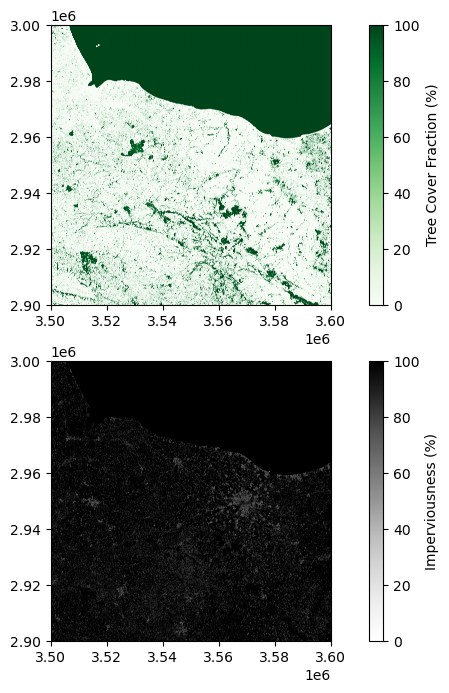

In [112]:
# hda_client = Client()

# # Search
# TCF_matches = hda_client.search({
#     "dataset_id": "EO:EEA:DAT:HRL:TCF",
#     "bbox": [lon_min_wgs84, lat_min_wgs84, lon_max_wgs84, lat_max_wgs84]
# })

# print("Tree Cover Fraction:")
# print(TCF_matches[-1])

# # Download + extract latest one
# TCF_files = download_and_extract(TCF_matches[-1],
#                              out_dir="/workspaces/DSM/data/TCF_original/",
#                              tmp_root="/workspaces/DSM/data/tmp")

# # Search
# IMP_matches = hda_client.search({
#     "dataset_id": "EO:EEA:DAT:HRL:IMP",
#     "bbox": [lon_min_wgs84, lat_min_wgs84, lon_max_wgs84, lat_max_wgs84]
# })


# print("Imperviousness:")
# print(IMP_matches[-1])

# # Download + extract latest one
# IMP_files = download_and_extract(IMP_matches[-1],
#                              out_dir="/workspaces/DSM/data/IMP_original/",
#                              tmp_root="/workspaces/DSM/data/tmp")
# # print("Extracted files:", files)

with rasterio.open(TCF_files[0]) as tcf_src, rasterio.open(IMP_files[0]) as imp_src:
    tcf_image = tcf_src.read(1)

    # Get bounds (xmin, ymin, xmax, ymax)
    bounds = tcf_src.bounds
    extent = (bounds.left, bounds.right, bounds.bottom, bounds.top)

    fig, ax = plt.subplots(2, 1, figsize=(10,8))
    im0 = ax[0].imshow(
        tcf_image,
        cmap="Greens",
        extent=extent,      # <-- HERE
        origin="upper", 
        vmin = 0,
        vmax = 100
    )
    fig.colorbar(im0, ax=ax[0], label="Tree Cover Fraction (%)")
    # plt.title(f"Tree Cover Fraction")
    # plt.xlabel("X (meters)")
    # plt.ylabel("Y (meters)")

    imp_image = imp_src.read(1)

    im1 = ax[1].imshow(imp_image,
        cmap="Greys",
        extent=extent,      # <-- HERE
        origin="upper", 
        vmin = 0,
        vmax = 100
    )
    fig.colorbar(im1, ax=ax[1], label="Imperviousness (%)")

    plt.show()


In [116]:
cop30m_path = os.path.join(data_dir, "cop_dem_30m_l93.tif")
dst_path, dst_transform = reproject_raster(
    src_path=TCF_files[0],       # your original COP DEM in EPSG:4326
    dst_path=cop30m_path,
    dst_crs="EPSG:2154",
    dst_resolution=30.0,       # meters per pixel, will be square
    resampling=Resampling.bilinear  # or Resampling.average for downsample
)

In [131]:
tcf_projected_l93_path = os.path.join(TCF_dir, "tcf_30m_l93.tif")
reproject_to_match(TCF_files[0], tcf_projected_l93_path, output_cop, resampling=Resampling.bilinear)

imp_projected_l93_path = os.path.join(IMP_dir, "imp_30m_l93.tif")
reproject_to_match(IMP_files[0], imp_projected_l93_path, output_cop, resampling=Resampling.bilinear)


    # Reproject a raster (src_path) so that it matches the CRS, transform, width, height
    # and grid of a reference raster (match_path), then save as dst_path.
    
    # Parameters:
    #     src_path : str
    #         Path to source raster to reproject.
    #     dst_path : str
    #         Path to output raster.
    #     match_path : str
    #         Path to reference raster (target grid).
    #     resampling : rasterio.warp.Resampling
    #         Resampling method (bilinear, average, nearest, etc.)
    # Returns:
    #     dst_path, transform : str, Affine
    #         Output path and transform of reprojected raster.

Reprojected raster saved to: /home/renauld/DSM/data_test_multimodality/Caen/TCF_original/tcf_30m_l93.tif
Reprojected raster saved to: /home/renauld/DSM/data_test_multimodality/Caen/IMP_original/imp_30m_l93.tif


('/home/renauld/DSM/data_test_multimodality/Caen/IMP_original/imp_30m_l93.tif',
 Affine(0.0002777777777777778, 0.0, -0.3070833444444361,
        0.0, -0.0002777777777777778, 49.20708334444444))

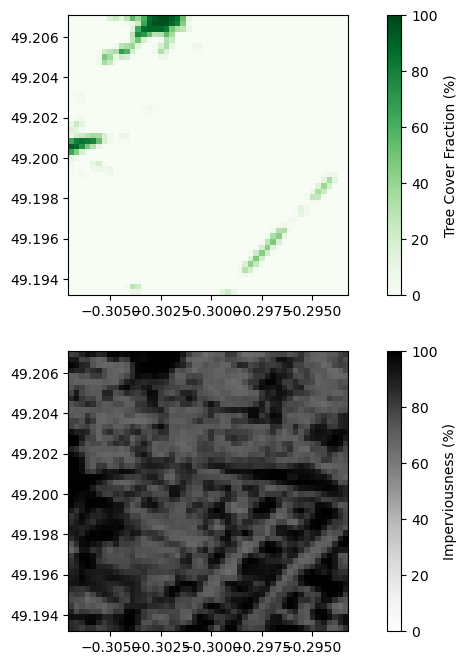

In [132]:
with rasterio.open(tcf_projected_l93_path) as tcf_src, rasterio.open(imp_projected_l93_path) as imp_src:
    tcf_image = tcf_src.read(1)

    # Get bounds (xmin, ymin, xmax, ymax)
    bounds = tcf_src.bounds
    extent = (bounds.left, bounds.right, bounds.bottom, bounds.top)

    fig, ax = plt.subplots(2, 1, figsize=(10,8))
    im0 = ax[0].imshow(
        tcf_image,
        cmap="Greens",
        extent=extent,      # <-- HERE
        origin="upper", 
        vmin = 0,
        vmax = 100
    )
    fig.colorbar(im0, ax=ax[0], label="Tree Cover Fraction (%)")

    imp_image = imp_src.read(1)

    im1 = ax[1].imshow(imp_image,
        cmap="Greys",
        extent=extent,      # <-- HERE
        origin="upper", 
        vmin = 0,
        vmax = 100
    )
    fig.colorbar(im1, ax=ax[1], label="Imperviousness (%)")

    plt.show()

In [ ]:
startDate = "2020-01-01T00:00:00.000Z"
completionDate = "2020-01-10T00:00:00.000Z"
target = "2020-01-01"

# Your JSON file:
S2_request = {
    "dataset_id": "EO:ESA:DAT:SENTINEL-2",
    "bbox": [lon_min_wgs84, lat_min_wgs84, lon_max_wgs84, lat_max_wgs84],
    "startDate": startDate,
    "completionDate": completionDate,
    "processingLevel": "S2MSI2A",
}

S2_matches = hda_client.search(S2_request)
print("Sentinel 2:")
print(S2_matches)

# S2_matches = hda_client.search(S2_request)
print(S2_matches.results[0].keys())
print("Sentinel 2:")
for i , item in enumerate(S2_matches.results):
    print(f"[{i+1}] ID: {item['id']}, Date: {item['properties']}")


KeyboardInterrupt: 

In [23]:
# This will return the dataset metadata, including all available fields you can filter on
dataset_info = hda_client.get_dataset("EO:ESA:DAT:SENTINEL-2")
print(dataset_info)

AttributeError: 'Client' object has no attribute 'get_dataset'

In [22]:
help(hda_client.search)

Help on method search in module hda.api:

search(query, limit=None) method of hda.api.Client instance
    Submits a search request with the given query.

    :param query: The JSON object representing the query.
    :type query: json

    :param limit: The maximum number of results to return.
        Set to None to return all results (default)
    :type limit: int

    :return: An :class:`hda.api.SearchResults` instance



In [ ]:
import rasterio
import matplotlib.pyplot as plt

with rasterio.open("T32TNN_20170802T101031_AOT_20m.jp2") as src:
    arr = src.read(1)               # read band
    transform = src.transform       # affine
    crs = src.crs                   # CRS object
    nodata = src.nodata
    profile = src.profile           # full metadata

    print("NoData value:", nodata)
    print("Profile:", profile)
    print("Transform:", transform)
    print("CRS:", crs)

    plt.imshow(arr, cmap='gray')
    plt.colorbar()
    plt.title("AOT Band")
    plt.show()


print(arr.shape, crs)